In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

### Data Prep & EDA


In [24]:
# Load the training dataset
file_path = "Phase 1 Training Dataset.xlsx"

# Load all sheets from the Excel file
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

# Read all sheets into a dictionary of dataframes
nh_data = {sheet: xls.parse(sheet) for sheet in sheet_names}

In [25]:
nh_data

{'Group 1':                  NH No.       1 Unnamed: 2 Unnamed: 3             NH No..1  \
 0                  Date     CNA        LPN         RN                 Date   
 1   2024-04-01 00:00:00   87.72      57.75      27.25  2024-04-01 00:00:00   
 2   2024-04-02 00:00:00   82.48      66.75      28.75  2024-04-02 00:00:00   
 3   2024-04-03 00:00:00   78.47      73.15       33.5  2024-04-03 00:00:00   
 4   2024-04-04 00:00:00   93.75      83.09      31.42  2024-04-04 00:00:00   
 ..                  ...     ...        ...        ...                  ...   
 87  2024-06-26 00:00:00  101.13      62.94       29.5  2024-06-26 00:00:00   
 88  2024-06-27 00:00:00     107         63      20.25  2024-06-27 00:00:00   
 89  2024-06-28 00:00:00  120.75      86.75      24.75  2024-06-28 00:00:00   
 90  2024-06-29 00:00:00   95.25      70.33       20.5  2024-06-29 00:00:00   
 91  2024-06-30 00:00:00   75.25      64.83      12.13  2024-06-30 00:00:00   
 
          2 Unnamed: 6 Unnamed: 7      

In [26]:
# Function to clean and structure each group's dataset with correctly assigned NH_IDs
def clean_group_data_fixed_nh_pattern(df, group_name):
    """
    Restructure the group dataframe into a standardized format.
    Assigns NH_ID values based on a repeating pattern every 4 columns.
    """
    # Convert column names to strings
    df.columns = df.columns.astype(str)

    # Define NH IDs based on column positions (every 4 columns = new NH)
    num_nhs = df.shape[1] // 4  # Total NHs in the group

    # Extract the data rows, skipping the first row (headers)
    df_cleaned = df.iloc[1:].reset_index(drop=True)

    # Create an empty list to store formatted data
    formatted_data = []

    # Process each NH's data
    for i in range(num_nhs):
        start_col = i * 4  # Each NH has 4 columns: Date, CNA, LPN, RN
        nh_df = df_cleaned.iloc[:, start_col:start_col + 4].copy()  # Extract relevant columns

        # Rename columns dynamically
        nh_df.columns = ["Date", "CNA", "LPN", "RN"]

        # Add NH_ID, Group, and derived features
        nh_df["NH_No"] = i + 1  # Assign NH_ID as 1, 2, 3, 4, 5 repeating
        group_numb = int(group_name.replace("Group ", ""))
        nh_df["Group"] = group_numb
            

        # Convert Date column to datetime
        nh_df["Date"] = pd.to_datetime(nh_df["Date"], errors="coerce")

        # Append formatted NH data
        formatted_data.append(nh_df)

    # Concatenate all NH data for this group
    return pd.concat(formatted_data, ignore_index=True)

# Apply corrected cleaning function to all groups and combine into a single dataset
all_data = pd.concat(
    [clean_group_data_fixed_nh_pattern(nh_data[group], group) for group in sheet_names],
    ignore_index=True
)

# Save cleaned data to CSV for future use
all_data.to_csv("Cleaned_NH_Staffing_Data.csv", index=False)

# Display final cleaned dataset
print("Final cleaned dataset saved as 'Cleaned_NH_Staffing_Data.csv'.")


Final cleaned dataset saved as 'Cleaned_NH_Staffing_Data.csv'.


In [27]:
print(all_data.head())

        Date     CNA    LPN     RN  NH_No  Group
0 2024-04-01   87.72  57.75  27.25      1      1
1 2024-04-02   82.48  66.75  28.75      1      1
2 2024-04-03   78.47  73.15   33.5      1      1
3 2024-04-04   93.75  83.09  31.42      1      1
4 2024-04-05  103.25   63.6  30.91      1      1


In [28]:
# Convert staffing hour columns to numeric
all_data["CNA"] = pd.to_numeric(all_data["CNA"], errors="coerce")
all_data["LPN"] = pd.to_numeric(all_data["LPN"], errors="coerce")
all_data["RN"] = pd.to_numeric(all_data["RN"], errors="coerce")

In [29]:
# Check for missing values
missing_values = all_data.isnull().sum()
print("Missing Values:\n", missing_values)

# Descriptive statistics
summary_stats = all_data.describe()
print("\nSummary Statistics:\n", summary_stats)

Missing Values:
 Date     0
CNA      0
LPN      0
RN       0
NH_No    0
Group    0
dtype: int64

Summary Statistics:
                                 Date          CNA          LPN           RN  \
count                           9100  9100.000000  9100.000000  9100.000000   
mean   2024-05-15 23:59:59.999999744   156.174100    55.050505    35.346429   
min              2024-04-01 00:00:00     0.000000     0.000000     0.000000   
25%              2024-04-23 00:00:00    87.047500    27.830000    15.000000   
50%              2024-05-16 00:00:00   132.075000    46.090000    28.500000   
75%              2024-06-08 00:00:00   207.167500    74.787500    48.322500   
max              2024-06-30 00:00:00   511.730000   227.310000   179.460000   
std                              NaN    94.793498    37.163644    27.478375   

             NH_No        Group  
count  9100.000000  9100.000000  
mean      3.000000    10.500000  
min       1.000000     1.000000  
25%       2.000000     5.750000  


In [30]:
all_data.head()

,Date,CNA,LPN,RN,NH_No,Group
0,2024-04-01,87.72,57.75,27.25,1,1
1,2024-04-02,82.48,66.75,28.75,1,1
2,2024-04-03,78.47,73.15,33.50,1,1
3,2024-04-04,93.75,83.09,31.42,1,1
4,2024-04-05,103.25,63.60,30.91,1,1


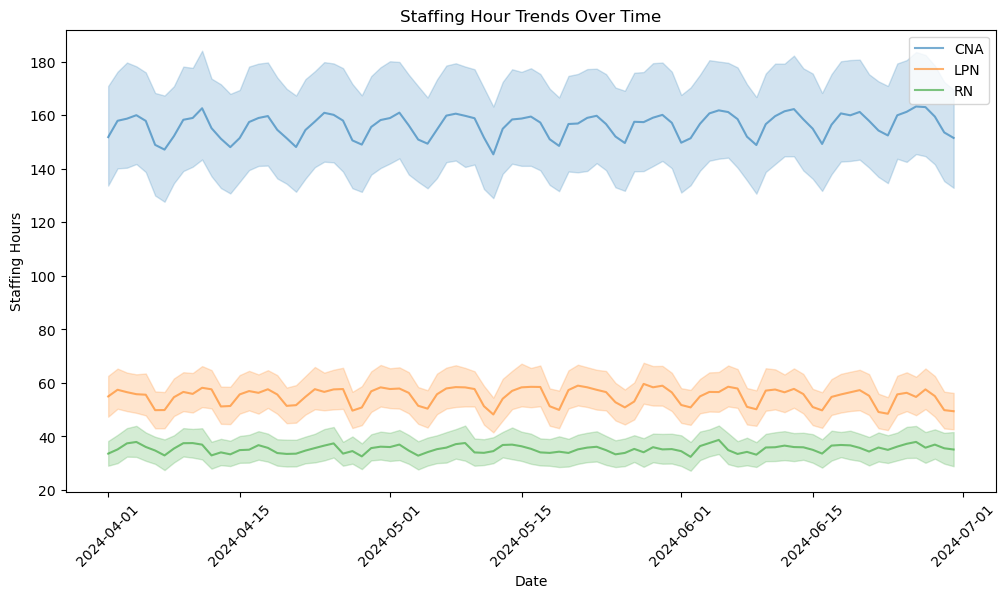

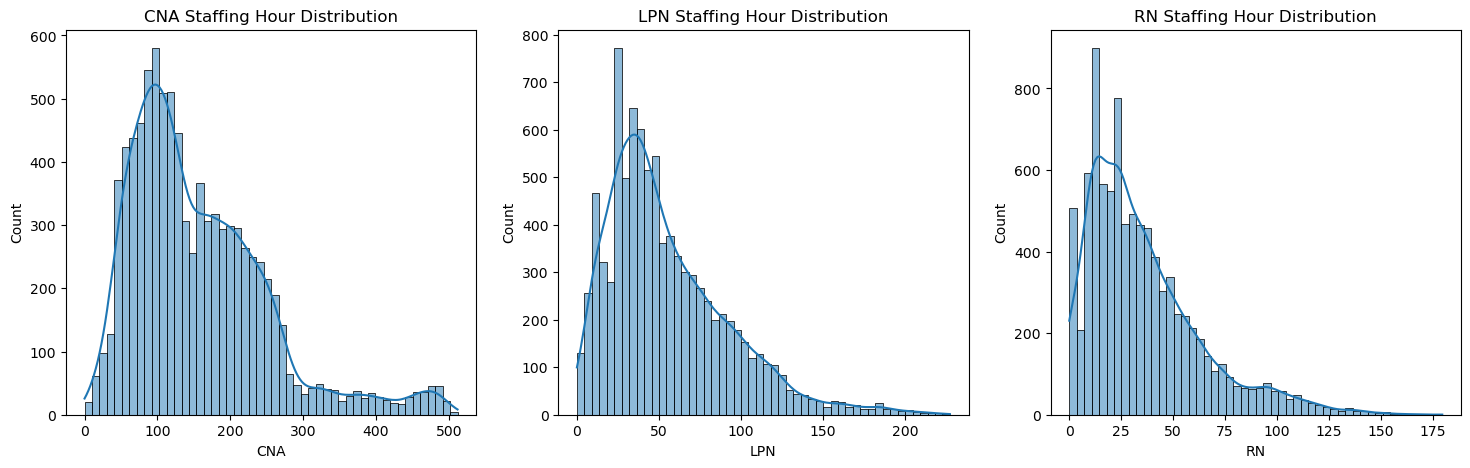

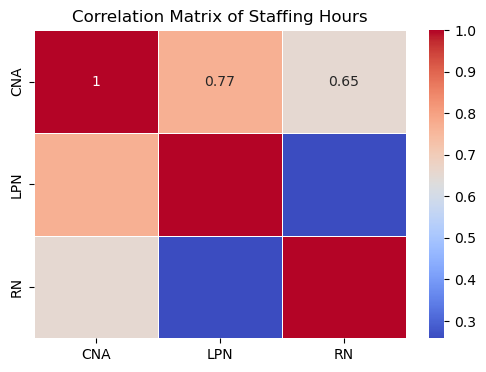

In [31]:
# Plot staffing hour trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=all_data, x="Date", y="CNA", label="CNA", alpha=0.6)
sns.lineplot(data=all_data, x="Date", y="LPN", label="LPN", alpha=0.6)
sns.lineplot(data=all_data, x="Date", y="RN", label="RN", alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Staffing Hours")
plt.title("Staffing Hour Trends Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Distribution of staffing hours
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(all_data["CNA"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("CNA Staffing Hour Distribution")
sns.histplot(all_data["LPN"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("LPN Staffing Hour Distribution")
sns.histplot(all_data["RN"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("RN Staffing Hour Distribution")
plt.show()

# correlation Matrix
correlation_matrix_fixed = all_data[["CNA", "LPN", "RN"]].corr()

# Display correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix_fixed, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Staffing Hours")
plt.show()


## Feature Engineering


In [ ]:
# Feature Engineering

def create_date_features(df):
    """
    Creates date-based features such as day of the week, weekend flag, and month.
    """
    df = df.copy()
    df["Day_of_Week"] = df["Date"].dt.dayofweek  # 0 = Monday, 6 = Sunday
    df["Is_Weekend"] = (df["Day_of_Week"] >= 5).astype(int)  # 1 if Saturday or Sunday
    df["Month"] = df["Date"].dt.month
    return df

def create_lag_features(df, lags=[1, 7, 14]):
    """
    Creates lag features for CNA, LPN, and RN staffing hours at the group level.
    Lags are specified in the `lags` parameter.
    """
    df = df.copy()
    for lag in lags:
        for col in ["CNA", "LPN", "RN"]:
            df[f"{col}_lag_{lag}"] = df.groupby(["Group"])[col].shift(lag)
    return df


def create_rolling_features(df, window=7):
    """
    Creates rolling mean and standard deviation features for CNA, LPN, and RN.
    This captures short-term trends in staffing hours at the group level.
    """
    df = df.copy()
    for col in ["CNA", "LPN", "RN"]:
        df[f"{col}_rolling_mean_{window}"] = df.groupby(["Group"])[col].rolling(window=window).mean().reset_index(level=0, drop=True)
        df[f"{col}_rolling_std_{window}"] = df.groupby(["Group"])[col].rolling(window=window).std().reset_index(level=0, drop=True)
    return df


def apply_feature_engineering(df):
    """
    Applies all feature engineering functions to a given dataset.
    """
    df = create_date_features(df)  # Add date-based features
    df = create_lag_features(df)   # Add lag features at group level
    df = create_rolling_features(df)  # Add rolling statistics at group level
    return df


In [ ]:
# Apply feature engineering to training data at GROUP level
train_data_fe = apply_feature_engineering(all_data)

# Compute group-level statistics from training data
# group_stats_train = create_group_statistics(train_data_fe)

In [ ]:
# Create test dataset with correct structure: each group should have all dates
num_groups = 20
date_range = pd.date_range(start="2024-04-01", end="2024-06-30")

# Create a DataFrame with all combinations of Date and Group
test_data = pd.DataFrame([(date, group) for group in range(1, num_groups + 1) for date in date_range], 
                         columns=["Date", "Group"])

# Apply date-based features
test_data_fe = create_date_features(test_data)

# Ensure "Group" column is a string in both datasets before merging
train_data_fe["Group"] = train_data_fe["Group"].astype(int)
test_data_fe["Group"] = test_data_fe["Group"].astype(int)


In [ ]:
test_data_fe

In [ ]:
train_data_fe

In [ ]:
train_data_fe[(train_data_fe["Date"] == "2024-04-01") & (train_data_fe["Group"] == 1)]

In [ ]:
# Select only the group-level columns from training (exclude NH_No)
group_level_cols = [col for col in train_data_fe.columns if col not in ["NH_No", "CNA", "LPN", "RN", "Is_Weekend", "Day_of_Week", "Month"]]
train_data_copy = train_data_fe[group_level_cols]

# Copy the group-level features from training data (excluding raw CNA, LPN, RN values)
group_features_train = train_data_copy.groupby(["Date", "Group"]).mean().reset_index()
# group_features_train = group_features_train.drop(columns=["NH_No"], errors="ignore")

In [ ]:
group_features_train

In [ ]:
# Merge these group-level features into test data based on Group & Date
test_data_fe = test_data_fe.merge(group_features_train, on=["Group", "Date"], how="left")
test_data_fe.info()

In [ ]:
train_data_fe.info()

In [ ]:
# Output of structured data
train_data_fe.to_csv("train_data_fe.csv", index=False)
test_data_fe.to_csv("test_data_fe.csv", index=False)

## Model training & prediction


#### Data for Modelling

- train_data_fe is the training data for 5 NH_No (feature engineering done)
- test_data_fe is the test data (feature engineering done)

#### Validation 1: Time-based validation

- need to create validation set: 20% of training_data
- calculate metrics: mae, mape, smape, mis
- output prediction with lower bound and upper bound


In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ----------------------------
# 2. Define Custom Quantile Loss Functions for XGBoost
# ----------------------------
# XGBoost does not have a built-in quantile regression objective.
# We implement the pinball loss as a custom objective function.
# For a given quantile τ, the pinball loss L is defined as:
#    L = τ * (y - f)  if (y - f) >= 0, and 
#    L = (τ - 1) * (y - f)  if (y - f) < 0.
# The gradient is:
#    grad = -τ  if (y - f) >= 0, and
#    grad = 1 - τ  if (y - f) < 0.
# We use a constant hessian as an approximation.

def quantile_loss_obj(preds, dtrain, quantile):
    labels = dtrain.get_label()
    errors = labels - preds
    # Calculate gradient: note that the sign is reversed because
    # we are differentiating with respect to predictions.
    grad = np.where(errors < 0, 1 - quantile, -quantile)
    # Hessian is not defined for the pinball loss; use a constant.
    hess = np.ones_like(labels)
    return grad, hess

# Custom evaluation function to monitor quantile loss during training.
def quantile_loss_eval(preds, dtrain, quantile):
    labels = dtrain.get_label()
    errors = labels - preds
    # Compute loss for each prediction.
    loss = np.where(errors >= 0, quantile * errors, (1 - quantile) * (-errors))
    return 'quantile_loss', np.mean(loss)

In [3]:

# The training data (train_data_fe.csv) contains the NH_No column (5 NHs per group)
# along with your engineered features and target staffing hour columns.
# The test data (test_data_fe.csv) does not include NH_No and is for a single NH per group.
train_data = pd.read_csv('train_data_fe.csv', parse_dates=['Date'])
test_data = pd.read_csv('test_data_fe.csv', parse_dates=['Date'])

def split_columns_by_target(df):
    """
    Splits DataFrame columns into three groups based on caregiver type.
    
    - Common columns (e.g., Date, Group) are those that do NOT contain 'CNA', 'LPN', or 'RN'
      in their name.
    - For each caregiver type, we take the common columns plus those columns whose names 
      contain the corresponding substring (e.g., "CNA", "LPN", or "RN").
    
    Returns:
        cna_cols, lpn_cols, rn_cols: Lists of column names for each caregiver type.
    """
    # Identify common columns that are not caregiver-specific.
    common_cols = [col for col in df.columns if ('CNA' not in col and 'LPN' not in col and 'RN' not in col)]
    
    # For each target, select columns that contain the substring.
    cna_specific = [col for col in df.columns if 'CNA' in col]
    lpn_specific = [col for col in df.columns if 'LPN' in col]
    rn_specific  = [col for col in df.columns if 'RN' in col]
    
    # Combine common columns with the caregiver-specific ones.
    cna_cols = common_cols + cna_specific
    lpn_cols = common_cols + lpn_specific
    rn_cols  = common_cols + rn_specific
    
    # Remove duplicates (if any) while preserving order.
    cna_cols = list(dict.fromkeys(cna_cols))
    lpn_cols = list(dict.fromkeys(lpn_cols))
    rn_cols  = list(dict.fromkeys(rn_cols))
    
    return cna_cols, lpn_cols, rn_cols

def data_modelling(train_data, test_data, target_col):
    # Assume the target columns are the staffing hours: 'Hrs_CNA', 'Hrs_LPN', and 'Hrs_RN'.
    target_cols = target_col

    # Remove the identifier column from the training data (if present)
    if 'NH_No' in train_data.columns:
        train_data_model = train_data.drop(columns=['NH_No'])
    else:
        train_data_model = train_data.copy()

    # Convert the Date column to ordinal (numeric) - object cannot
    train_data_model['Date'] = pd.to_datetime(train_data_model['Date'], errors='coerce')
    test_data['Date'] = pd.to_datetime(test_data['Date'], errors='coerce')

    # Define feature columns as those not in target_cols.
    feature_cols = [col for col in train_data_model.columns if col not in target_cols]

    # Sort the training data by the Date column.
    train_data_model_sorted = train_data_model.sort_values(by='Date')

    # Specify the split date
    split_date = pd.Timestamp('2024-06-12')

    # Create the training set (data before the split date) and validation set (data on/after the split date)
    train_data_final = train_data_model_sorted[train_data_model_sorted['Date'] < split_date]
    val_data_final = train_data_model_sorted[train_data_model_sorted['Date'] >= split_date]

    # Convert date to numerical
    train_data_final['Date'] = train_data_final['Date'].apply(lambda x: x.toordinal())
    val_data_final['Date'] = val_data_final['Date'].apply(lambda x: x.toordinal())
    test_data['Date'] = test_data['Date'].apply(lambda x: x.toordinal())

    # Extract features and targets for training and validation.
    X_train = train_data_final[feature_cols]
    y_train = train_data_final[target_cols]
    X_val = val_data_final[feature_cols]
    y_val = val_data_final[target_cols]

    return X_train, y_train, X_val, y_val

In [4]:
# Split columns for train and test data
train_cna_cols, train_lpn_cols, train_rn_cols = split_columns_by_target(train_data)
test_cna_cols, test_lpn_cols, test_rn_cols    = split_columns_by_target(test_data)

# Create separate DataFrames for each caregiver type.
train_cna = train_data[train_cna_cols]
train_lpn = train_data[train_lpn_cols]
train_rn  = train_data[train_rn_cols]

test_cna = test_data[test_cna_cols]
test_lpn = test_data[test_lpn_cols]
test_rn  = test_data[test_rn_cols]

# For CNA:
X_train_cna, y_train_cna, X_val_cna, y_val_cna = data_modelling(train_cna, test_cna, 'CNA')
# For LPN:
X_train_lpn, y_train_lpn, X_val_lpn, y_val_lpn = data_modelling(train_lpn, test_lpn, 'LPN')
# For RN:
X_train_rn,  y_train_rn,  X_val_rn,  y_val_rn  = data_modelling(train_rn, test_rn,  'RN')

# (Optional) Print shapes to verify the splits
print("CNA Train/Val shapes:", X_train_cna.shape, X_val_cna.shape)
print("LPN Train/Val shapes:", X_train_lpn.shape, X_val_lpn.shape)
print("RN Train/Val shapes: ", X_train_rn.shape,  X_val_rn.shape)


CNA Train/Val shapes: (7200, 10) (1900, 10)
LPN Train/Val shapes: (7200, 10) (1900, 10)
RN Train/Val shapes:  (7200, 10) (1900, 10)


In [5]:
# Metrics
def mae(y_true, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error with a threshold to avoid division by small numbers"""
    threshold = 1.0  # Use a threshold of 1.0 (adjust as needed)
    mask = y_true > threshold
    if not np.any(mask):
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def mis(y_true, lower, upper, alpha=0.05):
    """
    Mean Interval Score (MIS)
    MIS = (upper - lower) + (2/alpha)*((lower - y_true) * I(y_true < lower) + (y_true - upper) * I(y_true > upper))
    We use the median for robustness against outliers.
    """
    width = upper - lower
    penalty = (2/alpha) * ((lower - y_true) * (y_true < lower) + (y_true - upper) * (y_true > upper))
    return np.median(width + penalty)


In [6]:
# 6. Set Up the Modeling Strategy: Quantile Regression with XGBoost
# ----------------------------
# We choose three quantiles: 0.025 (lower bound), 0.5 (point/median prediction), and 0.975 (upper bound).
quantiles = [0.025, 0.5, 0.975]

# Define basic XGBoost parameters (you can further tune these per caregiver type)
params1 = {
    'max_depth': 4,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'verbosity': 0,
    'objective': 'reg:squarederror'
}
num_round = 1000  # Number of boosting rounds

params_cna = {
    'max_depth': 3,           # Increased depth for more complexity
    'eta': 0.15,              # Lower learning rate
    'subsample': 0.8,         # Slightly less aggressive subsampling
    'colsample_bytree': 0.9,  # More features per tree
    'gamma': 1,               # Adding gamma for regularization (adjust as needed)
    'lambda': 1,              # L2 regularization parameter
    'alpha': 0.1,             # L1 regularization parameter
    'verbosity': 0,
    'objective': 'reg:squarederror'  # Placeholder; custom objective will override this.
}
num_round_cna = 1000  # Increase number of rounds for lower learning rate

params2 = {
    'max_depth': 3,
    'eta': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'verbosity': 0,
    'objective': 'reg:squarederror'
}
num_round = 1000  # Number of boosting rounds

def train_quantile_model(X, y, quantile, params, num_round):
    dtrain = xgb.DMatrix(X, label=y)
    def obj(preds, dtrain):
        return quantile_loss_obj(preds, dtrain, quantile)
    def feval(preds, dtrain):
        return quantile_loss_eval(preds, dtrain, quantile)
    model = xgb.train(params, dtrain, num_round, obj=obj, feval=feval)
    return model

def train_models_for_target(X_train, y_train, quantiles, params, num_round):
    models = {}
    for q in quantiles:
        models[q] = train_quantile_model(X_train, y_train, q, params, num_round)
    return models

# Train separate models for each target.
models_cna = train_models_for_target(X_train_cna, y_train_cna, quantiles, params_cna, num_round)
models_lpn = train_models_for_target(X_train_lpn, y_train_lpn, quantiles, params1, num_round)
models_rn  = train_models_for_target(X_train_rn,  y_train_rn,  quantiles, params1, num_round)

In [11]:
# Model Evaluation
# Define a helper function to get predictions for a single target.
def get_predictions_for_target(models, X):
    """
    Given a dictionary of quantile models for one target (keys are quantiles),
    return a dictionary of predictions for each quantile.
    """
    preds = {}
    dmatrix = xgb.DMatrix(X)
    for q in quantiles:
        preds[q] = models[q].predict(dmatrix)
    return preds

def evaluate_target(models, X_train, X_val, y_train, y_val):
    """
    Evaluate the models for one target by computing MAE, MAPE, SMAPE, and MIS on 
    both the training and validation sets.
    Uses the 0.5 quantile as the point prediction, and 0.025 and 0.975 for the interval.
    """
    # Obtain predictions for training and validation sets.
    train_preds = get_predictions_for_target(models, X_train)
    val_preds = get_predictions_for_target(models, X_val)
    
    # Use the 0.5 quantile as the point forecast.
    y_train_pred = train_preds[0.5]
    y_val_pred = val_preds[0.5]
    
    # Compute point prediction metrics.
    train_mae   = mae(y_train, y_train_pred)
    val_mae     = mae(y_val, y_val_pred)
    train_mape  = mape(y_train, y_train_pred)
    val_mape    = mape(y_val, y_val_pred)
    train_smape = smape(y_train, y_train_pred)
    val_smape   = smape(y_val, y_val_pred)
    
    # For MIS, use the lower and upper quantile predictions.
    y_train_lower = train_preds[0.025]
    y_train_upper = train_preds[0.975]
    y_val_lower   = val_preds[0.025]
    y_val_upper   = val_preds[0.975]
    train_mis = mis(y_train, y_train_lower, y_train_upper, alpha=0.05)
    val_mis   = mis(y_val, y_val_lower, y_val_upper, alpha=0.05)
    
    # Print metrics.
    print("Training Set Metrics:")
    print(f"  MAE   : {train_mae:.3f}")
    print(f"  MAPE  : {train_mape:.3f}%")
    print(f"  SMAPE : {train_smape:.3f}%")
    print(f"  MIS   : {train_mis:.3f}")
    
    print("Validation Set Metrics:")
    print(f"  MAE   : {val_mae:.3f}")
    print(f"  MAPE  : {val_mape:.3f}%")
    print(f"  SMAPE : {val_smape:.3f}%")
    print(f"  MIS   : {val_mis:.3f}")

    return val_preds


print("\n--- CNA Evaluation ---")
val_pred1=evaluate_target(models_cna, X_train_cna, X_val_cna, y_train_cna, y_val_cna)

print("\n--- LPN Evaluation ---")
val_pred2=evaluate_target(models_lpn, X_train_lpn, X_val_lpn, y_train_lpn, y_val_lpn)

print("\n--- RN Evaluation ---")
val_pred3=evaluate_target(models_rn, X_train_rn, X_val_rn, y_train_rn, y_val_rn)


--- CNA Evaluation ---
Training Set Metrics:
  MAE   : 86.033
  MAPE  : 42.529%
  SMAPE : 59.185%
  MIS   : 198.693
Validation Set Metrics:
  MAE   : 88.073
  MAPE  : 42.697%
  SMAPE : 60.218%
  MIS   : 263.979

--- LPN Evaluation ---
Training Set Metrics:
  MAE   : 33.272
  MAPE  : 47.894%
  SMAPE : 67.757%
  MIS   : 179.354
Validation Set Metrics:
  MAE   : 32.261
  MAPE  : 49.316%
  SMAPE : 68.615%
  MIS   : 164.064

--- RN Evaluation ---
Training Set Metrics:
  MAE   : 17.803
  MAPE  : 41.438%
  SMAPE : 58.453%
  MIS   : 35.460
Validation Set Metrics:
  MAE   : 18.458
  MAPE  : 42.786%
  SMAPE : 58.308%
  MIS   : 36.461


In [13]:
val_pred1

{0.025: array([4.2257967, 4.2257967, 4.2257967, ..., 4.2257967, 4.2257967,
        4.2257967], dtype=float32),
 0.5: array([60.496586, 45.607815, 75.13161 , ..., 64.58088 , 72.94157 ,
        73.90221 ], dtype=float32),
 0.975: array([ 72.80724,  53.74945, 106.43687, ...,  88.74867,  99.01995,
        101.78468], dtype=float32)}

In [ ]:
# def get_test_predictions(models, test_df, target):
#     """
#     Given a dictionary of quantile models for one caregiver type and the test DataFrame,
#     returns a DataFrame with the following columns:
#       - Group (used for sheet separation)
#       - {target}_point (0.5 quantile prediction)
#       - {target}_lower (0.025 quantile prediction)
#       - {target}_upper (0.975 quantile prediction)
#     """
#     preds = get_predictions_for_target(models, test_df)
#     df_pred = test_df.copy()
#     df_pred[f'{target}_point'] = preds[0.5]
#     df_pred[f'{target}_lower'] = preds[0.025]
#     df_pred[f'{target}_upper'] = preds[0.975]
#     # Return only the Group column and the prediction columns.
#     return df_pred[['Group', f'{target}_point', f'{target}_lower', f'{target}_upper']]

# # ----------------------------
# # Generate Predictions for Each Caregiver Type on Test Data
# # ----------------------------
# # These variables (models_cna, models_lpn, models_rn) should have been trained
# # previously using your separate train/test splitting functions.
# # Similarly, test_cna, test_lpn, and test_rn are the caregiver-specific test DataFrames.
# test_cna_pred = get_test_predictions(models_cna, test_cna, 'CNA')
# test_lpn_pred = get_test_predictions(models_lpn, test_lpn, 'LPN')
# test_rn_pred  = get_test_predictions(models_rn,  test_rn,  'RN')

# # ----------------------------
# # Merge Predictions Across Targets
# # ----------------------------
# # We merge on the "Group" column. The final DataFrame will have columns:
# # Group, CNA_point, CNA_lower, CNA_upper, LPN_point, LPN_lower, LPN_upper, RN_point, RN_lower, RN_upper.
# final_test_pred = test_cna_pred.merge(test_lpn_pred, on='Group').merge(test_rn_pred, on='Group')

# # ----------------------------
# # Write Predictions to Excel: One Sheet per Group
# # ----------------------------
# excel_filename = 'Phase 1 Prediction Output.xlsx'
# writer = pd.ExcelWriter(excel_filename, engine='xlsxwriter')

# # Assume the "Group" column defines the groups (e.g., Group 1, Group 2, etc.)
# groups = final_test_pred['Group'].unique()

# for grp in groups:
#     # Subset the predictions for the current group.
#     grp_df = final_test_pred[final_test_pred['Group'] == grp]
#     # Name the sheet as "Group_1", "Group_2", etc.
#     sheet_name = f'Group_{grp}'
#     grp_df.to_excel(writer, sheet_name=sheet_name, index=False)

# # Save and close the Excel file.
# writer.save()
# print(f"Final predictions saved to '{excel_filename}'.")

KeyboardInterrupt: 

In [8]:
def get_test_predictions(models, test_df, target):
    """
    Given a dictionary of quantile models for one caregiver type and the test DataFrame,
    returns a DataFrame with the following columns:
      - Group (used for sheet separation)
      - {target}_point (0.5 quantile prediction)
      - {target}_lower (0.025 quantile prediction)
      - {target}_upper (0.975 quantile prediction)
    """
    preds = get_predictions_for_target(models, test_df)
    df_pred = test_df.copy()
    df_pred[f'{target}_point'] = preds[0.5]
    df_pred[f'{target}_lower'] = preds[0.025]
    df_pred[f'{target}_upper'] = preds[0.975]
    # Return only the Group column and the prediction columns.
    return df_pred[['Group', f'{target}_point', f'{target}_lower', f'{target}_upper']]

def get_test_predictions(models, test_df, target):
    """
    Given a dictionary of quantile models for one caregiver type and the test DataFrame,
    returns a DataFrame with the following columns:
      - Group (used for sheet separation)
      - {target}_point (0.5 quantile prediction)
      - {target}_lower (0.025 quantile prediction)
      - {target}_upper (0.975 quantile prediction)
    """
    preds = get_predictions_for_target(models, test_df)
    df_pred = test_df.copy()
    df_pred[f'{target}_point'] = preds[0.5]
    df_pred[f'{target}_lower'] = preds[0.025]
    df_pred[f'{target}_upper'] = preds[0.975]
    # Return only the Group column and the prediction columns.
    return df_pred[['Group', f'{target}_point', f'{target}_lower', f'{target}_upper']]

# ----------------------------
# Generate Predictions for Each Caregiver Type on Test Data
# ----------------------------
# These variables (models_cna, models_lpn, models_rn) should have been trained
# previously using your separate train/test splitting functions.
# Similarly, test_cna, test_lpn, and test_rn are the caregiver-specific test DataFrames.
test_cna_pred = get_test_predictions(models_cna, test_cna, 'CNA')
test_lpn_pred = get_test_predictions(models_lpn, test_lpn, 'LPN')
test_rn_pred  = get_test_predictions(models_rn,  test_rn,  'RN')

# ----------------------------
# Merge Predictions Across Targets
# ----------------------------
# We merge on the "Group" column. The final DataFrame will have columns:
# Group, CNA_point, CNA_lower, CNA_upper, LPN_point, LPN_lower, LPN_upper, RN_point, RN_lower, RN_upper.
# Merge predictions as before.
final_test_pred = test_cna_pred.merge(test_lpn_pred, on='Group').merge(test_rn_pred, on='Group')



In [9]:
final_test_pred.head()

,Group,CNA_point,CNA_lower,CNA_upper,LPN_point,LPN_lower,LPN_upper,RN_point,RN_lower,RN_upper
0,1,75.131607,4.225797,129.776917,24.939049,1.742803,47.290173,19.421885,1.348187,31.969543
1,1,75.131607,4.225797,129.776917,24.939049,1.742803,47.290173,20.414358,1.651527,33.396957
2,1,75.131607,4.225797,129.776917,24.939049,1.742803,47.290173,20.676588,1.679643,33.915974
3,1,75.131607,4.225797,129.776917,24.939049,1.742803,47.290173,20.779205,1.681772,34.169575
4,1,75.131607,4.225797,129.776917,24.939049,1.742803,47.290173,21.470657,1.689578,35.030602


In [ ]:
# Group the DataFrame by 'Group' into a dictionary.
group_dict = {grp: grp_df for grp, grp_df in final_test_pred.groupby('Group')}

# Write the grouped DataFrames to Excel using a context manager.
excel_filename = 'Phase 1 Prediction Output.xlsx'
with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
    for grp, df in group_dict.items():
        # Name each sheet according to the group, e.g., "Group_1", "Group_2", etc.
        sheet_name = f'Group_{grp}'
        df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"Final predictions saved to '{excel_filename}'.")
